In [1]:
metadata <- read.table('/syn1/liangzhen/jinhua_jilab_project/result/SPATIAL/T2/spacia_metadata.txt',sep=',',header=T,row.names = 1)
metadata$cellID <- paste0(metadata$x,'_',metadata$y) 
rownames(metadata) <- metadata$cellID
metadata$first_type <- as.character(metadata$first_type)
metadata <- metadata[metadata$first_type %in% c('1','2','3','4','5'),]
metadata

,orig.ident,nCount_RNA,nFeature_RNA,orig.ident.1,x,y,percent.mt,nCount_SCT,nFeature_SCT,SCT_snn_res.0.8,⋯,conv_all,conv_doublet,AP1_signature1,EMT1,Spp1,Fosb,Jun,Cd44,state3_signature1,cellID
,<chr>,<int>,<int>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<int>,⋯,<lgl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1650_2700,lung,583,305,sample,1650,2700,1.0291595,5252,1343,12,⋯,TRUE,TRUE,0.0003442918,0.17254895,4.796357,0,0.000000,0.000000,-0.042709122,1650_2700
1650_3050,lung,507,254,sample,1650,3050,0.1972387,5168,1396,12,⋯,TRUE,TRUE,0.0076522719,0.01297065,0.000000,0,0.000000,0.000000,-0.034727613,1650_3050
1650_3450,lung,400,219,sample,1650,3450,0.0000000,4995,1456,12,⋯,TRUE,TRUE,0.0292574969,0.03051673,3.931826,0,0.000000,0.000000,-0.056232085,1650_3450
1650_4350,lung,615,309,sample,1650,4350,0.4878049,5239,1311,1,⋯,TRUE,TRUE,0.0576845662,0.17118082,5.097434,0,0.000000,3.512152,-0.019232157,1650_4350
1650_4450,lung,738,355,sample,1650,4450,0.6775068,5277,1275,8,⋯,TRUE,TRUE,0.0550931276,0.13891012,0.000000,0,0.000000,3.335779,-0.031390271,1650_4450
1650_4600,lung,418,242,sample,1650,4600,0.7177033,5220,1471,8,⋯,TRUE,TRUE,0.0155194565,0.05296243,0.000000,0,0.000000,0.000000,0.087432106,1650_4600
1650_8600,lung,542,262,sample,1650,8600,0.3690037,5167,1350,12,⋯,TRUE,TRUE,-0.0103179750,0.03289993,0.000000,0,0.000000,0.000000,0.071082797,1650_8600
1650_8750,lung,1148,491,sample,1650,8750,0.4355401,5361,1088,12,⋯,TRUE,TRUE,0.1101125776,0.11379273,2.273239,0,0.000000,2.913524,-0.056869131,1650_8750
1650_8800,lung,873,412,sample,1650,8800,1.3745704,5249,1197,1,⋯,TRUE,TRUE,0.1169061457,0.09995825,3.846289,0,0.000000,3.174276,0.049187007,1650_8800


Scale for y is already present.
Adding another scale for y, which will replace the existing scale.


png 
  2

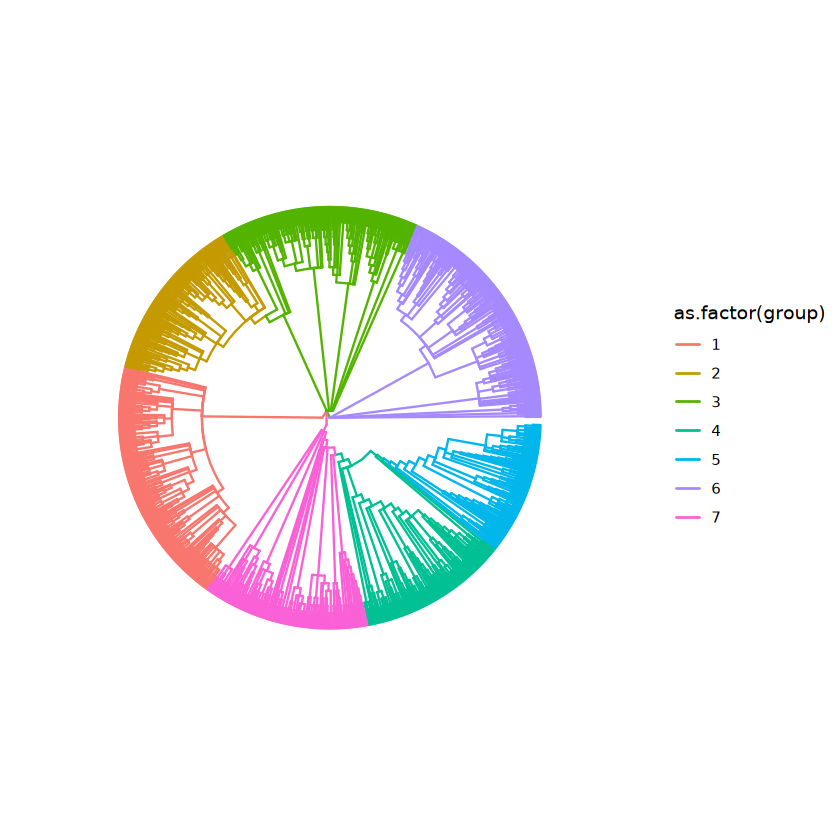

In [25]:
library(ape)
library(ggtree)
library(ggplot2)
library(cluster)

my_tree <- read.tree('/syn1/liangzhen/jinhua_jilab_project/result/DNA_Amplicon/SPATIAL/T2/trees/bin50_align_reads10/EE_tree/C3-1732.phy.treefile')
my_tree <- root(my_tree, outgroup = "synthetic", resolve.root = TRUE)
my_tree$edge.length <- rep(1,length(my_tree$edge.length))
my_tree <- drop.tip(my_tree,my_tree$tip.label[!my_tree$tip.label %in% metadata$cellID])
my_tree$edge.length <- rep(1,length(my_tree$edge.length))
dist_matrix <- cophenetic.phylo(my_tree)
hc <- hclust(as.dist(dist_matrix), method = "ward.D")
subgroups <- cutree(hc, k = 6)
subgroups[names(subgroups) %in% clade7] <- '7'
subgroups_list <- split(names(subgroups), subgroups)

my_tree_grouped <- groupOTU(my_tree, subgroups_list)
pdf('/syn1/liangzhen/jinhua_jilab_project/result/Figures/Figure3/spatial_c3_7clades_tree.pdf',width=6,6)
p <- ggtree(my_tree_grouped, aes(color = as.factor(group)),layout = 'fan', open.angle = 2,branch.length='none') + 
  #geom_tiplab(size = 3, align = TRUE) +  # align=TRUE 让标签右对齐
  #scale_color_manual(breaks = c('1','2','4','6','7','8','10','12','14','15','20'),
  #  values = c('#a6cee3','#1f78b4','#b2df8a','#33a02c','#fb9a99','#e31a1c','#fdbf6f','#ff7f00','#cab2d6','#6a3d9a',"grey70"),
 #   na.value = "grey70",
 #   name = "Subgroup"
 # ) +
  theme_tree(legend.position = "right") +
  #ggtitle("Phylogenetic Tree with 5 Subgroups") +
  xlim(0, max(ape::node.depth.edgelength(my_tree)) * 1.2)  # 给标签留空间

print(p)
dev.off()
print(p)

In [21]:
clade7 <- as.data.frame(p$data[p$data$isTip == TRUE & p$data$group=='3' & p$data$y > 700,'label'])$label
clade3 <- as.data.frame(p$data[p$data$isTip == TRUE & p$data$group=='3' & p$data$y < 700,'label'])$label

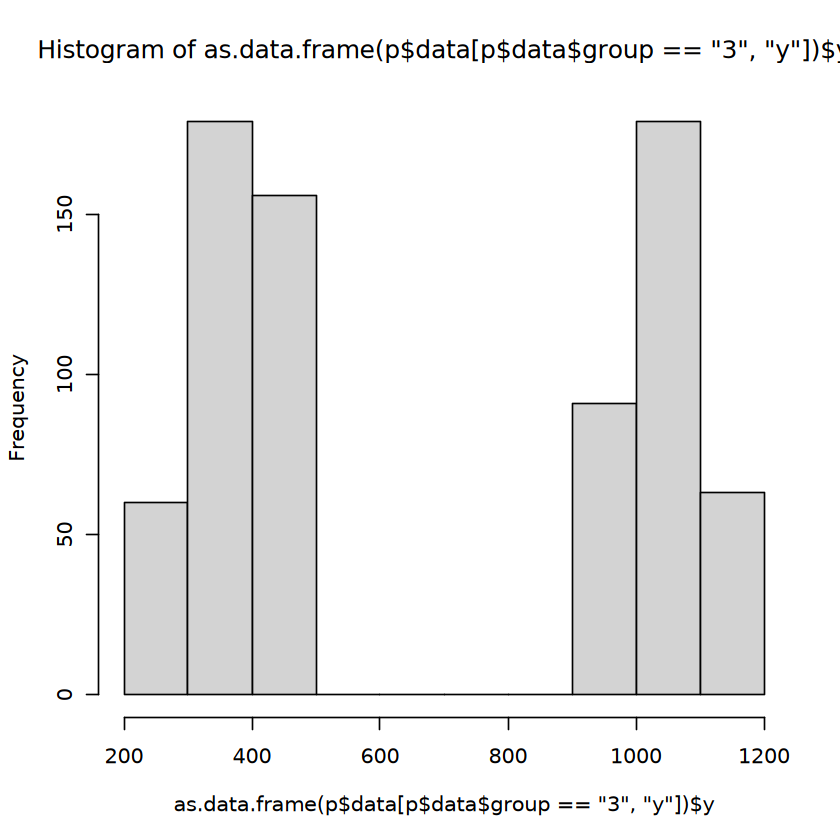

In [10]:
hist(as.data.frame(p$data[p$data$group=='3','y'])$y)

In [184]:
table(subgroups)

subgroups
  1   2   3   4   5   6 
277 185 408 166 149 265 

In [185]:
names(table(subgroups))

[1] "1" "2" "3" "4" "5" "6"

In [26]:
T2_metadata <- read.table('/syn1/liangzhen/jinhua_jilab_project/result/SPATIAL/T2/spacia_metadata.txt',sep=',',header = T,row.names = 1)
rownames(T2_metadata) <- paste0(T2_metadata$x,'_',T2_metadata$y)
T2_metadata$celltype <- T2_metadata$first_type
T2_metadata

,orig.ident,nCount_RNA,nFeature_RNA,orig.ident.1,x,y,percent.mt,nCount_SCT,nFeature_SCT,SCT_snn_res.0.8,⋯,conv_all,conv_doublet,AP1_signature1,EMT1,Spp1,Fosb,Jun,Cd44,state3_signature1,celltype
,<chr>,<int>,<int>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<int>,⋯,<lgl>,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>
1650_2700,lung,583,305,sample,1650,2700,1.0291595,5252,1343,12,⋯,TRUE,TRUE,0.0003442918,0.17254895,4.796357,0,0.000000,0.000000,-0.04270912,4
1650_3050,lung,507,254,sample,1650,3050,0.1972387,5168,1396,12,⋯,TRUE,TRUE,0.0076522719,0.01297065,0.000000,0,0.000000,0.000000,-0.03472761,4
1650_3450,lung,400,219,sample,1650,3450,0.0000000,4995,1456,12,⋯,TRUE,TRUE,0.0292574969,0.03051673,3.931826,0,0.000000,0.000000,-0.05623209,2
1650_3550,lung,420,216,sample,1650,3550,0.7142857,5141,1443,12,⋯,TRUE,TRUE,0.0056633065,0.09001731,3.211228,0,0.000000,4.566825,-0.08904737,Monocyte
1650_4100,lung,371,200,sample,1650,4100,1.3477089,5081,1485,5,⋯,TRUE,TRUE,-0.0202788806,0.07191127,3.330567,0,0.000000,0.000000,-0.04558104,Fibroblast
1650_4150,lung,422,220,sample,1650,4150,0.9478673,5090,1438,12,⋯,TRUE,TRUE,0.0043819546,0.01840632,3.206669,0,0.000000,0.000000,-0.05209065,Macrophage
1650_4200,lung,471,247,sample,1650,4200,1.6985138,5198,1421,12,⋯,TRUE,TRUE,0.0602925878,0.10051466,3.101507,0,0.000000,0.000000,0.04607235,T_cell
1650_4300,lung,545,270,sample,1650,4300,0.5504587,5230,1349,5,⋯,TRUE,TRUE,0.0216515797,0.20689490,0.000000,0,2.962621,0.000000,0.01689375,Fibroblast
1650_4350,lung,615,309,sample,1650,4350,0.4878049,5239,1311,1,⋯,TRUE,TRUE,0.0576845662,0.17118082,5.097434,0,0.000000,3.512152,-0.01923216,2


In [27]:
clone_clade <- as.data.frame(subgroups)
clone_clade$subgroups <- as.character(clone_clade$subgroups)
clone_clade

,subgroups
,<chr>
10000_10100,1
10000_9600,1
10300_9550,1
10500_9050,1
11250_9600,1
11000_8900,1
9050_8700,1
9850_10350,1
9250_6100,1


In [28]:
T2_metadata$clade <- clone_clade[rownames(T2_metadata),'subgroups']
T2_metadata

,orig.ident,nCount_RNA,nFeature_RNA,orig.ident.1,x,y,percent.mt,nCount_SCT,nFeature_SCT,SCT_snn_res.0.8,⋯,conv_doublet,AP1_signature1,EMT1,Spp1,Fosb,Jun,Cd44,state3_signature1,celltype,clade
,<chr>,<int>,<int>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<int>,⋯,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1650_2700,lung,583,305,sample,1650,2700,1.0291595,5252,1343,12,⋯,TRUE,0.0003442918,0.17254895,4.796357,0,0.000000,0.000000,-0.04270912,4,NA
1650_3050,lung,507,254,sample,1650,3050,0.1972387,5168,1396,12,⋯,TRUE,0.0076522719,0.01297065,0.000000,0,0.000000,0.000000,-0.03472761,4,NA
1650_3450,lung,400,219,sample,1650,3450,0.0000000,4995,1456,12,⋯,TRUE,0.0292574969,0.03051673,3.931826,0,0.000000,0.000000,-0.05623209,2,NA
1650_3550,lung,420,216,sample,1650,3550,0.7142857,5141,1443,12,⋯,TRUE,0.0056633065,0.09001731,3.211228,0,0.000000,4.566825,-0.08904737,Monocyte,NA
1650_4100,lung,371,200,sample,1650,4100,1.3477089,5081,1485,5,⋯,TRUE,-0.0202788806,0.07191127,3.330567,0,0.000000,0.000000,-0.04558104,Fibroblast,NA
1650_4150,lung,422,220,sample,1650,4150,0.9478673,5090,1438,12,⋯,TRUE,0.0043819546,0.01840632,3.206669,0,0.000000,0.000000,-0.05209065,Macrophage,NA
1650_4200,lung,471,247,sample,1650,4200,1.6985138,5198,1421,12,⋯,TRUE,0.0602925878,0.10051466,3.101507,0,0.000000,0.000000,0.04607235,T_cell,NA
1650_4300,lung,545,270,sample,1650,4300,0.5504587,5230,1349,5,⋯,TRUE,0.0216515797,0.20689490,0.000000,0,2.962621,0.000000,0.01689375,Fibroblast,NA
1650_4350,lung,615,309,sample,1650,4350,0.4878049,5239,1311,1,⋯,TRUE,0.0576845662,0.17118082,5.097434,0,0.000000,3.512152,-0.01923216,2,NA


In [33]:
T2_metadata

,orig.ident,nCount_RNA,nFeature_RNA,orig.ident.1,x,y,percent.mt,nCount_SCT,nFeature_SCT,SCT_snn_res.0.8,⋯,conv_doublet,AP1_signature1,EMT1,Spp1,Fosb,Jun,Cd44,state3_signature1,celltype,clade
,<chr>,<int>,<int>,<chr>,<int>,<int>,<dbl>,<int>,<int>,<int>,⋯,<lgl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<chr>,<chr>
1650_2700,lung,583,305,sample,1650,2700,1.0291595,5252,1343,12,⋯,TRUE,0.0003442918,0.17254895,4.796357,0,0.000000,0.000000,-0.04270912,4,NA
1650_3050,lung,507,254,sample,1650,3050,0.1972387,5168,1396,12,⋯,TRUE,0.0076522719,0.01297065,0.000000,0,0.000000,0.000000,-0.03472761,4,NA
1650_3450,lung,400,219,sample,1650,3450,0.0000000,4995,1456,12,⋯,TRUE,0.0292574969,0.03051673,3.931826,0,0.000000,0.000000,-0.05623209,2,NA
1650_3550,lung,420,216,sample,1650,3550,0.7142857,5141,1443,12,⋯,TRUE,0.0056633065,0.09001731,3.211228,0,0.000000,4.566825,-0.08904737,Monocyte,NA
1650_4100,lung,371,200,sample,1650,4100,1.3477089,5081,1485,5,⋯,TRUE,-0.0202788806,0.07191127,3.330567,0,0.000000,0.000000,-0.04558104,Fibroblast,NA
1650_4150,lung,422,220,sample,1650,4150,0.9478673,5090,1438,12,⋯,TRUE,0.0043819546,0.01840632,3.206669,0,0.000000,0.000000,-0.05209065,Macrophage,NA
1650_4200,lung,471,247,sample,1650,4200,1.6985138,5198,1421,12,⋯,TRUE,0.0602925878,0.10051466,3.101507,0,0.000000,0.000000,0.04607235,T_cell,NA
1650_4300,lung,545,270,sample,1650,4300,0.5504587,5230,1349,5,⋯,TRUE,0.0216515797,0.20689490,0.000000,0,2.962621,0.000000,0.01689375,Fibroblast,NA
1650_4350,lung,615,309,sample,1650,4350,0.4878049,5239,1311,1,⋯,TRUE,0.0576845662,0.17118082,5.097434,0,0.000000,3.512152,-0.01923216,2,NA


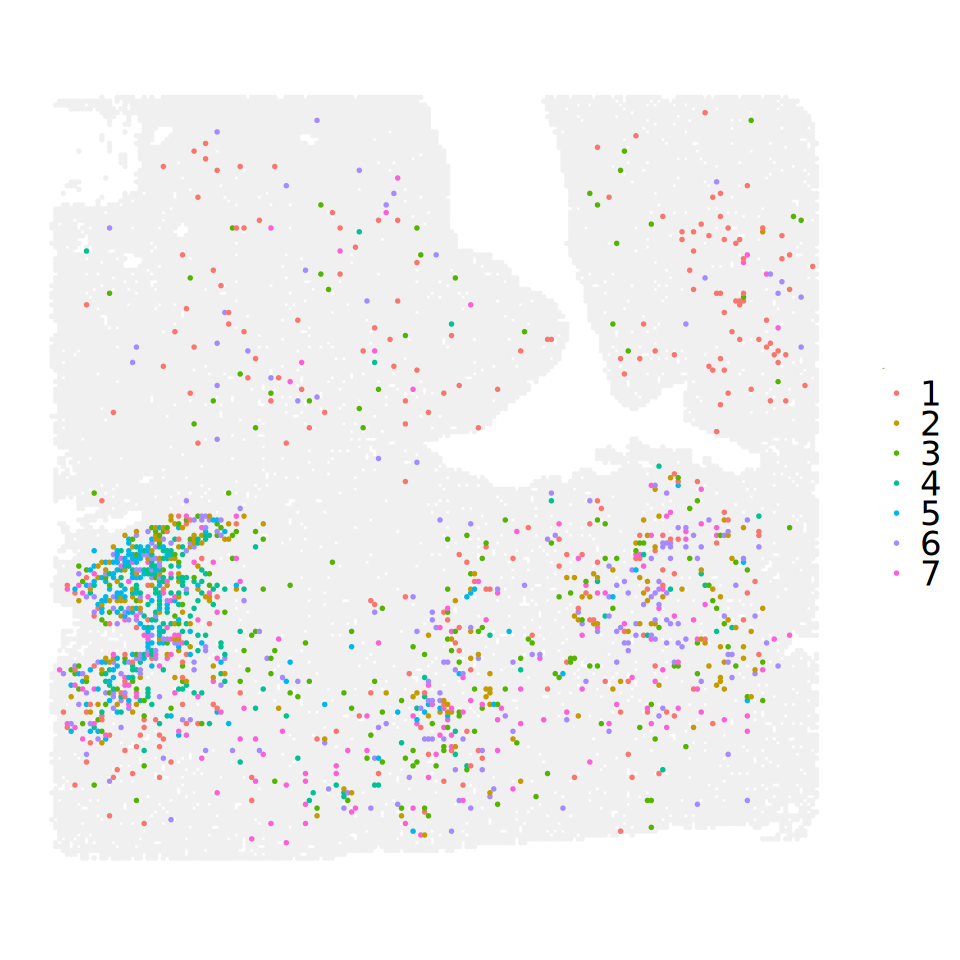

In [40]:
options(repr.plot.width = 8, repr.plot.height = 8)
plot <- ggplot() + geom_point(data = T2_metadata,aes(x=x,y=y),size=0.5,color='#f0f0f0')+ 
    geom_point(data = T2_metadata[!is.na(T2_metadata$clade),],aes(x=x,y=y,color=clade),size=0.5)+ 
    coord_fixed(ratio = 1) +theme_bw()+ 
    theme(panel.grid=element_blank(),axis.ticks = element_blank(),panel.border = element_blank(),
                  axis.text = element_blank(),axis.title = element_blank(),
                 legend.text=element_text(size=20),legend.title=element_text(size=0)
         )#+ theme(legend.position="none")
print(plot)

In [41]:
pdf('/syn1/liangzhen/jinhua_jilab_project/result/Figures/Figure3/spatial_c3_7clades_umap.pdf',width=5,5)

options(repr.plot.width = 8, repr.plot.height = 8)
plot <- ggplot() + geom_point(data = T2_metadata,aes(x=x,y=y),size=0.5,color='#f0f0f0')+ 
    geom_point(data = T2_metadata[!is.na(T2_metadata$clade),],aes(x=x,y=y,color=clade),size=0.5)+ 
    coord_fixed(ratio = 1) +theme_bw()+ 
    theme(panel.grid=element_blank(),axis.ticks = element_blank(),panel.border = element_blank(),
                  axis.text = element_blank(),axis.title = element_blank(),
                 legend.text=element_text(size=20),legend.title=element_text(size=0)
         )#+ theme(legend.position="none")
print(plot)
options(repr.plot.width = 5, repr.plot.height = 5)
for (clade in c('1','2','3','4','5','6','7')){
    plot <- ggplot() + geom_point(data = T2_metadata,aes(x=x,y=y),size=0.5,color='#f0f0f0')+ 
        geom_point(data = T2_metadata[T2_metadata$clade == clade,],aes(x=x,y=y,color=clade),size=1)+ 
        coord_fixed(ratio = 1) +theme_bw()+ 
        theme(panel.grid=element_blank(),axis.ticks = element_blank(),panel.border = element_blank(),
                      axis.text = element_blank(),axis.title = element_blank(),
                     legend.text=element_text(size=20),legend.title=element_text(size=0)
             )#+ theme(legend.position="none")
    print(plot)    
}
dev.off()


Warning message:
“Removed 31960 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 31960 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 31960 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 31960 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 31960 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 31960 rows containing missing values or values outside the scale range
(`geom_point()`).”
Warning message:
“Removed 31960 rows containing missing values or values outside the scale range
(`geom_point()`).”


png 
  2